# Autoencoders

# **Compresión de datos**

La compresión de datos es una fase esencial en el entrenamiento de una red. 

La idea es comprimir los datos para que que la misma cantidad de información puede representarse con menos bits.

**Codificador automático (Auto Encoder (AE)**

Autoencoder se usa para aprender incrustaciones eficientes de datos sin etiquetar para una configuración de red determinada. 

Consta de dos partes, un **codificador y un decodificador**

**El codificador** comprime los datos de un espacio de mayor dimensión a un espacio de menor dimensión (también
llamado espacio latente), mientras que el **decodificador** vuelve a convertir el espacio latente en un espacio de mayor dimensión.

Toda la arquitectura de codificador-decodificador se entrena colectivamente en la función de pérdida que fomenta que la entrada se reconstruya en la salida. Por lo tanto, la función de pérdida es el error cuadrático medio
entre la entrada del codificador y la salida del decodificador.

La variable latente no está regularizada. Elegir una variable latente aleatoria generará una salida de basura.

La variable latente son valores deterministas y el espacio carece de la capacidad generativa

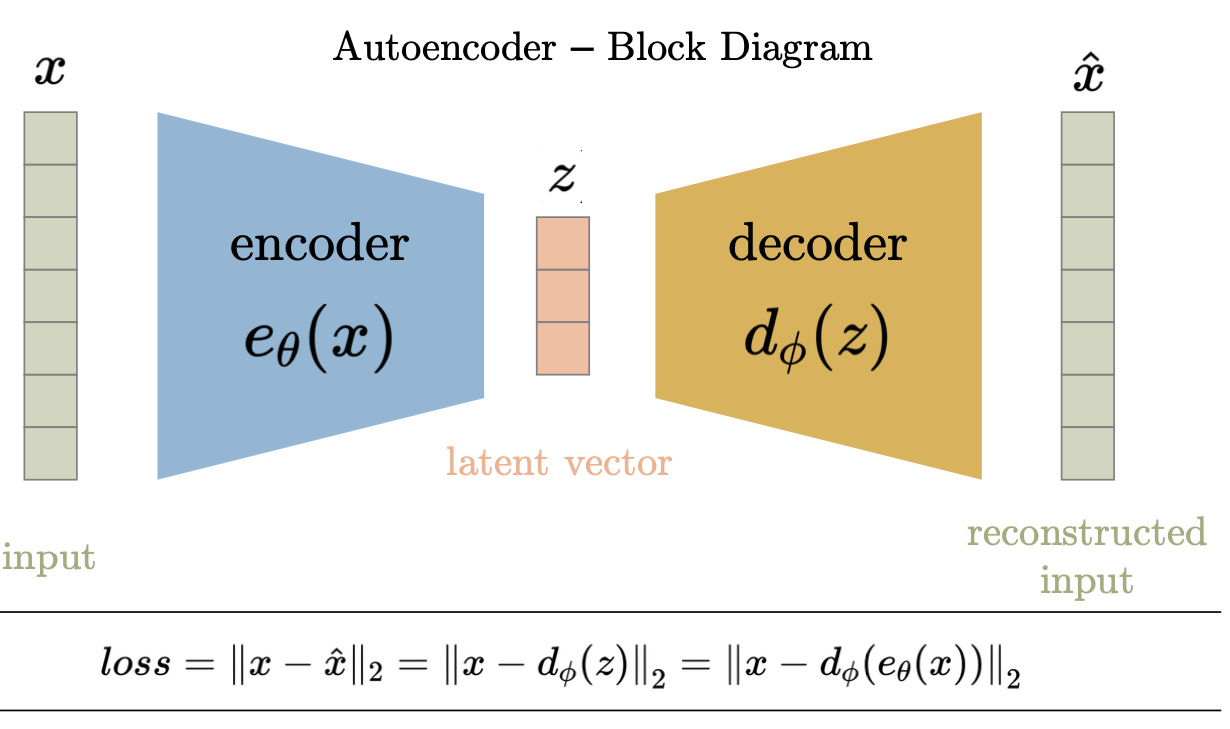

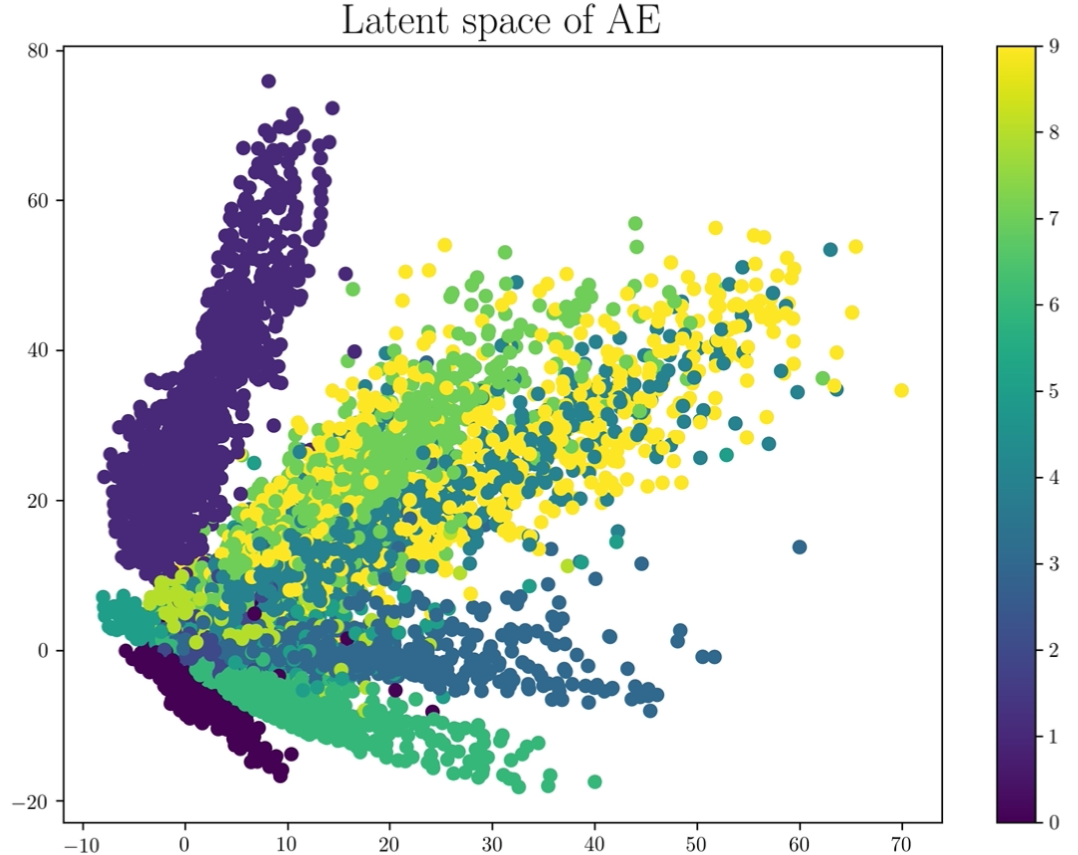

La "codificación automática" es un algoritmo de compresión de datos en el que las funciones de compresión y descompresión son 1) específicas de los datos, 2) con pérdida y 3) aprendidas automáticamente a partir de ejemplos en lugar de ser diseñadas por un ser humano. 


Además, en casi todos los contextos donde se usa el término "autocodificador", las funciones de compresión y descompresión se implementan con **redes neuronales**

1.-**¿Son buenos para comprimir información?**
Por lo general, no realmente. En la compresión de imágenes, por ejemplo, es bastante difícil entrenar un codificador automático que haga un mejor trabajo que un algoritmo básico como JPEG y, por lo general, la única forma de lograrlo es restringiéndose a un tipo de imagen muy específico (por ejemplo, uno para que JPEG no hace un buen trabajo). El hecho de que los codificadores automáticos sean específicos de los datos los hace generalmente poco prácticos para los problemas de compresión de datos del mundo real: solo puede usarlos en datos que son similares a los que fueron entrenados, y hacerlos más generales requiere muchos datos de entrenamiento. Pero los avances futuros podrían cambiar esto, quién sabe.

2.-**¿Para qué son buenos?**
Hoy en día, dos aplicaciones prácticas interesantes de los codificadores automáticos son la eliminación de ruido de datos y la reducción de dimensionalidad para la visualización de datos. Con las restricciones adecuadas de dimensionalidad y escasez, los codificadores automáticos pueden aprender proyecciones de datos que son más interesantes que PCA u otras técnicas básicas.

Para la visualización 2D específicamente, t-SNE (pronunciado "tee-snee") es probablemente el mejor algoritmo que existe, pero generalmente requiere datos de dimensiones relativamente bajas. Entonces, una buena estrategia para visualizar relaciones de similitud en datos de alta dimensión es comenzar usando un codificador automático para comprimir sus datos en un espacio de baja dimensión (por ejemplo, 32 dimensiones), luego use t-SNE para mapear los datos comprimidos a un plano 2D.  El algoritmo está en Keras y scikit-learn. 
https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding

In [3]:
import keras
from keras import layers

# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)


In [4]:
# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)


In [5]:
# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))


In [6]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()


In [8]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)


(60000, 784)
(10000, 784)


In [9]:
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


Epoch 1/50
235/235 [==============================] - 2s 6ms/step - loss: 0.2772 - val_loss: 0.1911
Epoch 2/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1708 - val_loss: 0.1532
Epoch 3/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1446 - val_loss: 0.1342
Epoch 4/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1290 - val_loss: 0.1214
Epoch 5/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1185 - val_loss: 0.1133
Epoch 6/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1114 - val_loss: 0.1073
Epoch 7/50
235/235 [==============================] - 1s 5ms/step - loss: 0.1064 - val_loss: 0.1031
Epoch 8/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1028 - val_loss: 0.1000
Epoch 9/50
235/235 [==============================] - 1s 6ms/step - loss: 0.1001 - val_loss: 0.0977
Epoch 10/50
235/235 [==============================] - 1s 6ms/step - loss: 0.0981 - val_loss: 0.0960

In [10]:
# Encode and decode some digits
# Note that we take them from the *test* set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)


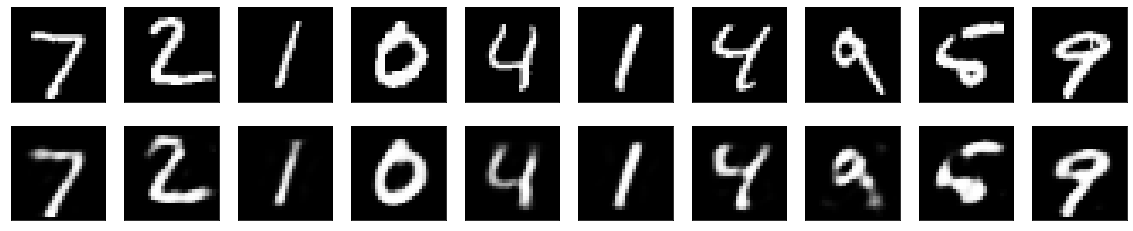

In [11]:
# Use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


# Variational Auto Encoder (VAE)

El autocodificador variacional (Variational Auto Encoder) aborda el problema del espacio latente no regularizado en
Autoencoder y proporciona la capacidad generativa a todo el espacio. 

En lugar de generar los vectores en el espacio latente, el codificador de VAE genera parámetros de una
distribución predefinida en el espacio latente para cada input. 

El VAE luego impone una restricción en esta distribución latente forzándola a ser una distribución normal.

La variable latente en forma comprimida es la media y la varianza. 

La función de pérdida de VAE en el entrenamiento se define como la suma de la pérdida de reconstrucción y la pérdida de similitud. (Divergencia Kullback-Leibler (KL) entre la distribución gaussiana unitaria y de salida del decodificador)

La variable latente es suave y continua, es decir, los valores aleatorios de la variable latente generan
salida significativa en el decodificador, por lo tanto, el espacio latente tiene capacidades generativas

La entrada del decodificador se muestrea a partir de una gaussiana con media/varianza de la salida del codificador

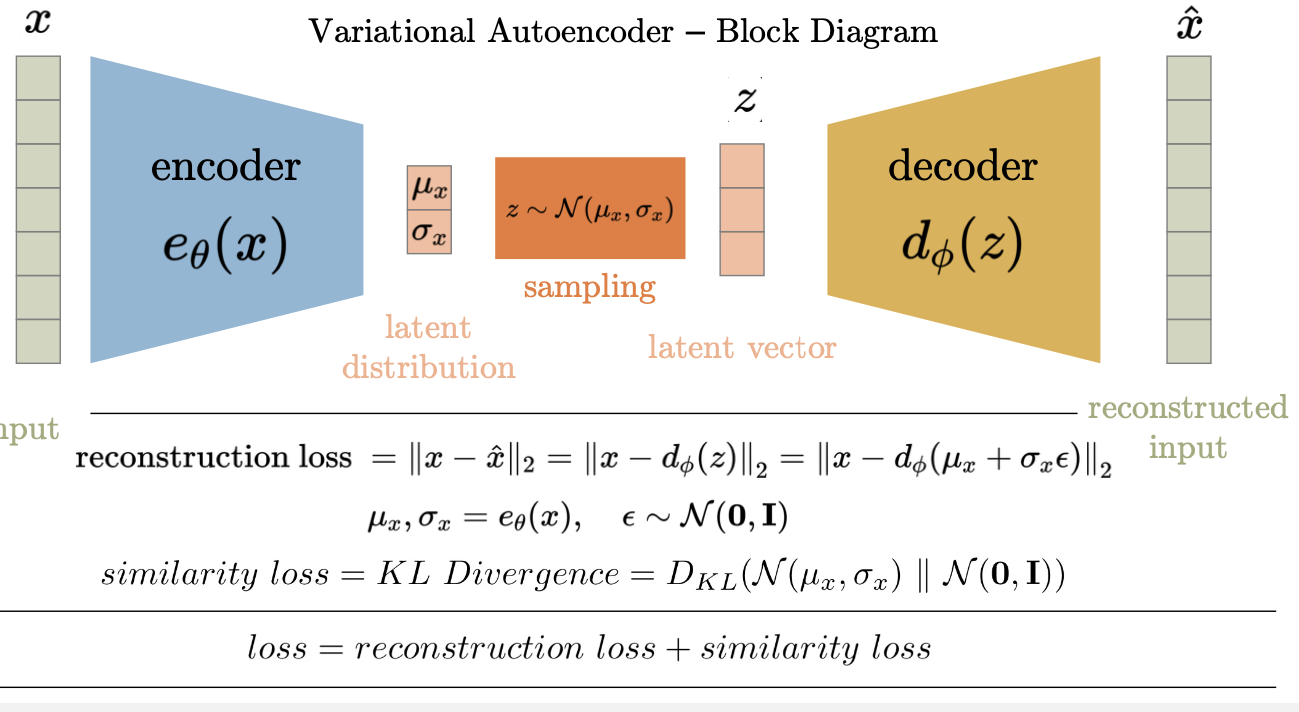

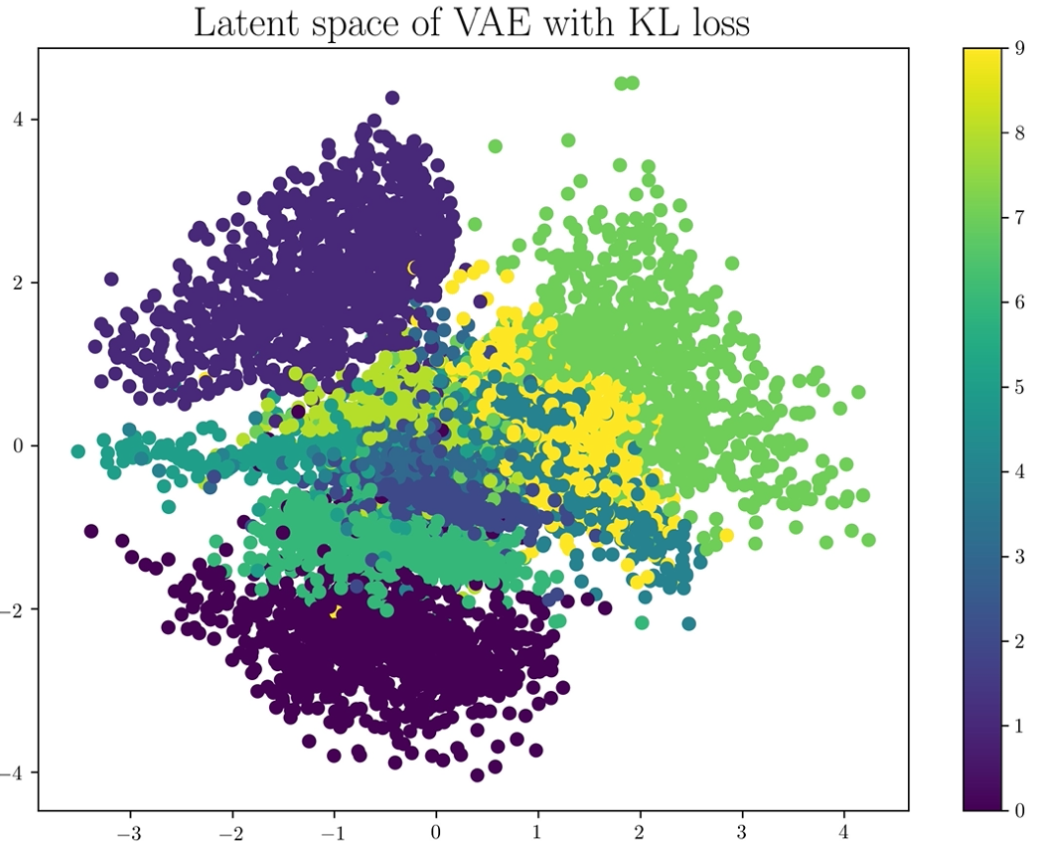

Los codificadores automáticos variacionales (Variational AutoEncoder (VAE)) son una versión un poco más moderna e interesante de la codificación automática.

**¿Qué es un codificador automático variacional?**
Es un tipo de codificador automático con restricciones adicionales sobre las representaciones codificadas que se aprenden. Más precisamente, es un codificador automático que aprende un modelo de variable latente para sus datos de entrada. Entonces, en lugar de dejar que su red neuronal aprenda una función arbitraria, está aprendiendo los parámetros de una distribución de probabilidad que modela sus datos. Si toma muestras de puntos de esta distribución, puede generar nuevas muestras de datos de entrada: un VAE es un "modelo generativo"

**¿Cómo funciona un autocodificador variacional?**

Primero, una red codificadora convierte las muestras de entrada x en dos parámetros en un espacio latente, que anotaremos z_mean y z_log_sigma. Luego, muestreamos aleatoriamente puntos z similares de la distribución normal latente que se supone que genera los datos, mediante z = z_mean + exp(z_log_sigma) * epsilon, donde epsilon es un tensor normal aleatorio. Finalmente, una red decodificadora asigna estos puntos de espacio latentes a los datos de entrada originales.

Los parámetros del modelo se entrenan a través de dos funciones de pérdida: una pérdida de reconstrucción que obliga a las muestras decodificadas a coincidir con las entradas iniciales (al igual que en nuestros codificadores automáticos anteriores), y la divergencia KL entre la distribución latente aprendida y la distribución anterior, que actúa como un plazo de regularización. De hecho, podría deshacerse de este último término por completo, aunque ayuda a aprender espacios latentes bien formados y a reducir el sobreajuste de los datos de entrenamiento.

In [12]:
original_dim = 28 * 28
intermediate_dim = 64
latent_dim = 2

inputs = keras.Input(shape=(original_dim,))
h = layers.Dense(intermediate_dim, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_sigma = layers.Dense(latent_dim)(h)


In [13]:
from keras import backend as K

def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim),
                              mean=0., stddev=0.1)
    return z_mean + K.exp(z_log_sigma) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_sigma])


In [14]:
# Create encoder
encoder = keras.Model(inputs, [z_mean, z_log_sigma, z], name='encoder')

# Create decoder
latent_inputs = keras.Input(shape=(latent_dim,), name='z_sampling')
x = layers.Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = layers.Dense(original_dim, activation='sigmoid')(x)
decoder = keras.Model(latent_inputs, outputs, name='decoder')

# instantiate VAE model
outputs = decoder(encoder(inputs)[2])
vae = keras.Model(inputs, outputs, name='vae_mlp')


In [15]:
reconstruction_loss = keras.losses.binary_crossentropy(inputs, outputs)
reconstruction_loss *= original_dim
kl_loss = 1 + z_log_sigma - K.square(z_mean) - K.exp(z_log_sigma)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')


In [17]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

vae.fit(x_train, x_train,
        epochs=10,
        batch_size=32,
        validation_data=(x_test, x_test))


Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 158.1454 - val_loss: 157.6331
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 156.6525 - val_loss: 156.2284
Epoch 3/10
1875/1875 [==============================] - 4s 2ms/step - loss: 155.4257 - val_loss: 155.0126
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 154.4890 - val_loss: 154.4771
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 153.7369 - val_loss: 153.6996
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 153.1384 - val_loss: 153.1012
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 152.6131 - val_loss: 152.6038
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 152.1706 - val_loss: 152.1936
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 151.7670 - val_loss: 152.2431
Epoch 10/10
1875/1875 [=======================

In [18]:
x_test_vae = vae.predict(x_test, batch_size=32)


In [19]:
x_test.shape

(10000, 784)

In [20]:
x_test_vae.shape

(10000, 784)

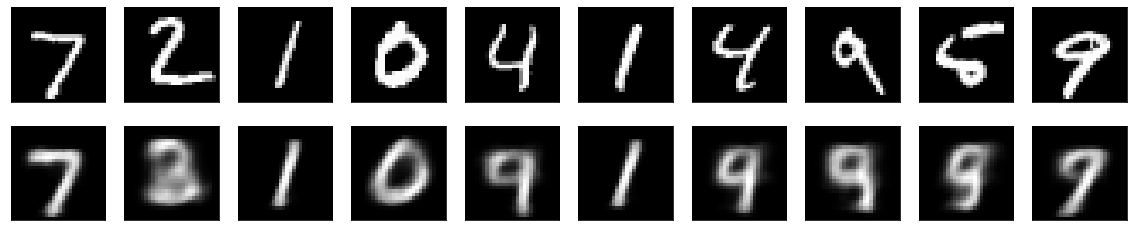

In [21]:
# Use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_vae[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [22]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

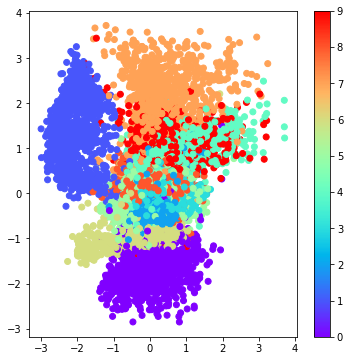

In [23]:
x_test_encoded = encoder.predict(x_test, batch_size=32)
plt.figure(figsize=(6, 6))
plt.scatter(x_test_encoded[2][:, 0], x_test_encoded[2][:, 1], c=y_test,cmap="rainbow")
plt.colorbar()
plt.show()


# Ejercicio Finanzas
Usaremos un Variational AutoEncoder paa reducir las dimensiones de un vector de Series de Tiempo con 388 Series a 2 dimensiones. 

Los Autoencoders son algoritmos no supervisados usados para comprimir información. Se construyen, como ya mencionamos, con un Encoder, Decoder y una Función de Pérdida para medir la pérdida de información entre la información que se hizo la compresión y descompresión. 

https://arxiv.org/abs/1312.6114 (más información de modelos de VAE)

El objetivo de nuestro proyecto es detectar acciones que estén cerca de otra acción en el mismo mercado o de una clase de activo diferente en otro mercado.

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#descarga info de Carteras
#observa cuál es el más cercano a Biotech

In [ ]:
#Crea un índice de Biotech

In [25]:
stock_data=pd.read_excel("/Users/CarlosCarrasco/Documents/Work/Covid/Archivos R/Working/2022-02-11_Carteras_Info.xlsx",sheet_name='Datos')


In [26]:
stock_data.head()

,Fecha,ESCALA,ACTICOB,ACTOTAL,ACTI500,ESFERA,ROBOTIK,DINAMO,SNX,SALUD,...,FINX,SNSR,AUSF,AIQ,CTEC,GNOM,MILN,KRMA,BUG,HERO
0,1999-01-04,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,NaN,8.421189,NaN,4.408552,NaN,NaN,9.556062,6.390187,NaN,3.972161
1,1999-01-05,100.007452,100.008484,100.008841,101.352089,101.349906,101.349073,100.540648,101.187779,101.565005,...,NaN,8.647502,NaN,4.494844,NaN,NaN,9.812874,6.499619,NaN,4.049911
2,1999-01-06,100.014044,100.016108,100.016822,103.589872,103.585429,103.583733,101.427887,103.022749,103.245873,...,NaN,8.864071,NaN,4.633786,NaN,NaN,10.058628,6.649946,NaN,4.175100
3,1999-01-07,100.021359,100.024454,100.025526,103.371044,103.364350,103.361794,101.341909,102.699467,102.759012,...,NaN,8.893670,NaN,4.644228,NaN,NaN,10.092216,6.583103,NaN,4.184508
4,1999-01-08,100.029368,100.033496,100.034925,103.801094,103.792116,103.788688,101.510700,103.145001,104.020732,...,NaN,8.919592,NaN,4.680805,NaN,NaN,10.121632,6.626537,NaN,4.217465


In [27]:
stock_data=stock_data.set_index(['Fecha'])

In [28]:
stock_data.shape

(5820, 553)

In [29]:
stock_data.dropna(inplace=True)

In [30]:
stock_data.shape

(732, 553)

Text(0.5, 1.0, 'Sample Time Series')

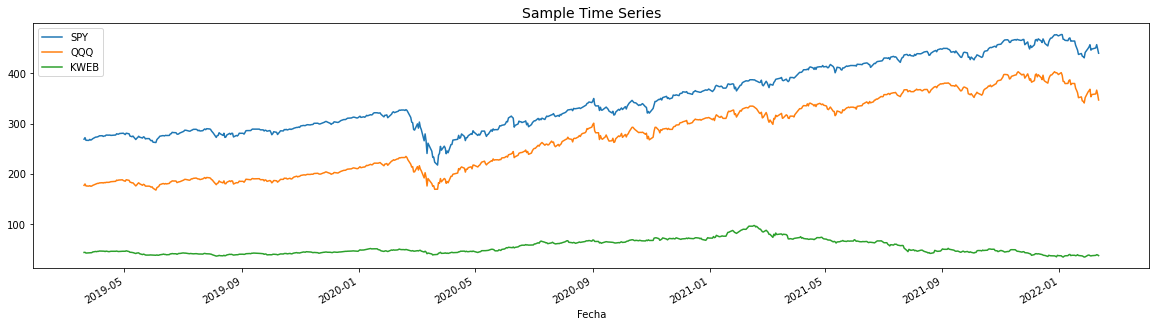

In [31]:
fig, axis = plt.subplots(figsize=(20,5))
stock_data[['SPY','QQQ','KWEB']].plot(ax = axis)
axis.set_title('Sample Time Series', fontsize = 14)

**Promedio móvil geométrico**

El promedio móvil geométrico calcula una serie de medias geométricas de diferentes subconjuntos del conjunto de datos completo. Para comparar series de tiempo de varios rangos de precios, calcularemos la serie de tiempo media móvil geométrica de rendimientos que se define como:

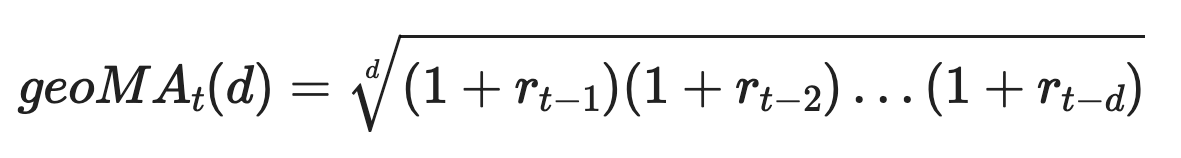

donde $r_t$ es el rendimiento del activo financiero para el día t.


Elegimos d=5 porque estamos interesados en el promedio móvil geométrico semanal y una semana comercial típica tiene 5 días hábiles.

Para cada día dado, calcularemos el promedio móvil geométrico de los últimos 5 días hábiles.

Para calcular el geoMA(5), primero debemos calcular el cambio porcentual diario de ambos marcos de datos.

In [260]:
stock_data_pct_change = stock_data.pct_change()
stock_data_pct_change.dropna(inplace = True)
stock_data_pct_change.tail()

,ESCALA,ACTICOB,ACTOTAL,ACTI500,ESFERA,ROBOTIK,DINAMO,SNX,SALUD,SPY,...,FINX,SNSR,AUSF,AIQ,CTEC,GNOM,MILN,KRMA,BUG,HERO
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-02-04,-0.005922,-0.006019,-0.006374,0.000746,-0.000010,0.003499,-0.004266,0.001322,-0.007173,0.004702,...,0.038826,0.000000,0.000325,0.021323,0.020777,0.014696,0.022982,0.005020,0.025723,0.032900
2022-02-08,0.001594,0.001147,0.001866,0.006554,-0.006514,0.012707,0.006251,0.006914,0.013479,0.004992,...,0.004558,0.013490,0.007511,0.004848,-0.006162,0.011965,0.003209,0.004371,0.018461,0.005926
2022-02-09,0.000466,0.000496,0.000764,0.014957,0.026678,0.027943,0.005493,0.015113,0.017830,0.014636,...,0.047187,0.030671,0.009724,0.025813,0.054685,0.042937,0.028526,0.017097,0.025650,0.029455
2022-02-10,0.003994,0.003811,0.004366,-0.011077,-0.011287,-0.012827,-0.000266,-0.008591,-0.012143,-0.017966,...,-0.022819,-0.025828,-0.013483,-0.017164,-0.031704,-0.028043,-0.020218,-0.017421,-0.001334,-0.025751
2022-02-11,0.003149,0.000003,0.000003,-0.018969,-0.018969,-0.018969,-0.007586,-0.015183,-0.013323,-0.019897,...,-0.033402,-0.023919,-0.005532,-0.033531,-0.028649,-0.023941,-0.027513,-0.019285,-0.023372,-0.018722


In [262]:
kweb=stock_data_pct_change[["KWEB"]]

In [266]:
stock_data_pct_change=stock_data_pct_change.drop(["KWEB"],axis=1)

In [40]:
stock_data_pct_change=stock_data_pct_change.iloc[:,9:20]

In [267]:
geoMA_5d_stocks = pd.DataFrame(columns = stock_data_pct_change.columns, index = stock_data_pct_change.index)

d = 5
for i in range(len(geoMA_5d_stocks.columns)):
    for j in range(d,len(geoMA_5d_stocks)):
        mult = 1
        for k in range(1,1+d):
            mult = mult * (stock_data_pct_change.loc[stock_data_pct_change.index[j-k]][geoMA_5d_stocks.columns[i]]+1)
            geoMA_5d_stocks.loc[geoMA_5d_stocks.index[j]][geoMA_5d_stocks.columns[i]] = np.power(mult,1/d)
            


In [268]:
geoMA_5d_stocks

,ESCALA,ACTICOB,ACTOTAL,ACTI500,ESFERA,ROBOTIK,DINAMO,SNX,SALUD,SPY,...,FINX,SNSR,AUSF,AIQ,CTEC,GNOM,MILN,KRMA,BUG,HERO
Fecha,,,,,,,,,,,,,,,,,,,,,
2019-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-03-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-02-04,0.999535,0.999469,0.999998,1.006562,1.008101,1.008562,1.000832,1.005653,1.008278,1.007024,...,1.004414,1.00591,1.00568,1.006335,1.005986,1.010686,1.004717,1.005551,1.009179,1.006554
2022-02-08,0.99906,0.998789,0.999224,1.002488,1.006598,1.005754,1.000089,1.001844,1.00257,1.003036,...,1.004746,1.003078,1.002551,1.005175,1.009897,1.007733,1.003896,1.002263,1.009237,1.011497
2022-02-09,0.99947,0.99923,0.999515,1.000303,0.998839,1.000382,1.0003,1.000274,1.002271,1.000457,...,0.994818,0.998273,1.002149,0.997255,0.993109,0.999131,0.996988,0.998823,1.004296,1.005008


In [269]:
# We drop the NaN lines (the first 5 lines will contain NaN values due as we are calculating a 5-day moving average)
geoMA_5d_stocks.dropna(inplace=True)

In [270]:
geoMA_5d_stocks_T=geoMA_5d_stocks.T

In [271]:
geoMA_5d_stocks_T

Fecha,2019-03-28,2019-03-29,2019-04-01,2019-04-02,2019-04-03,2019-04-04,2019-04-05,2019-04-08,2019-04-09,2019-04-10,...,2022-01-28,2022-01-31,2022-02-01,2022-02-02,2022-02-03,2022-02-04,2022-02-08,2022-02-09,2022-02-10,2022-02-11
ESCALA,1.000774,1.000725,1.000328,0.999504,0.999655,0.99943,0.999555,0.99958,1.000126,1.000126,...,0.999601,0.999397,0.999017,1.000116,0.99821,0.999535,0.99906,0.99947,0.999144,1.000582
ACTICOB,1.000021,1.000031,0.999726,0.999724,0.999706,0.9997,0.999711,1.000025,1.000019,1.00003,...,0.999913,0.999789,0.999335,1.000358,0.99866,0.999469,0.998789,0.99923,0.998985,1.000381
ACTOTAL,1.00003,1.000034,0.999708,0.99972,0.99972,0.999722,0.999719,1.000051,1.000049,1.000053,...,0.999399,0.999531,0.999396,1.000534,0.998754,0.999998,0.999224,0.999515,0.999205,1.000833
ACTI500,0.998552,0.99701,1.001927,1.004413,1.003024,1.004407,1.004199,1.004065,1.001928,1.000801,...,0.992864,1.001682,1.004219,1.008979,1.009234,1.006562,1.002488,1.000303,1.00154,0.998247
ESFERA,0.997873,0.997286,1.001927,1.005546,1.003437,1.004322,1.004727,1.004453,1.001651,1.000588,...,0.985034,0.991348,1.00083,1.008521,1.007321,1.008101,1.006598,0.998839,1.001299,0.998138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GNOM,0.994244,0.993319,1.006028,1.005486,1.004441,1.010969,1.006704,1.0071,1.005988,0.999389,...,0.985553,0.995353,1.003001,1.011389,1.010371,1.010686,1.007733,0.999131,1.002767,1.002225
MILN,1.000282,0.998566,1.004524,1.005126,1.004827,1.006557,1.004616,1.00391,1.00254,1.001578,...,0.987903,0.999564,1.004741,1.012484,1.01165,1.004717,1.003896,0.996988,1.000052,0.997845
KRMA,0.999522,0.998328,1.003143,1.006209,1.004354,1.00446,1.004467,1.004702,1.001512,1.000572,...,0.99268,0.99976,1.003308,1.006814,1.009654,1.005551,1.002263,0.998823,1.002277,0.997102
BUG,0.996504,0.994036,1.00157,1.00504,1.005152,1.007734,1.00552,1.004166,1.001706,0.99983,...,0.986296,0.996321,1.003603,1.013629,1.011827,1.009179,1.009237,1.004296,1.007571,1.00962


Text(0, 0.5, '5-day Geometric MA')

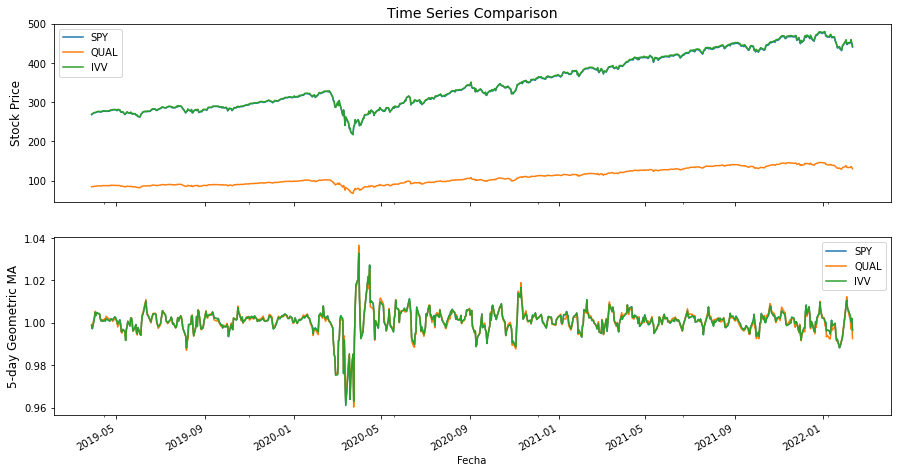

In [272]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(15,8))
stock_data[['SPY','QUAL','IVV']].loc[geoMA_5d_stocks.index[0]:].plot(ax=axes[0])
axes[0].set_ylabel('Stock Price', fontsize = 12)
axes[0].set_title('Time Series Comparison', fontsize = 14)
geoMA_5d_stocks[['SPY','QUAL','IVV']].plot(ax=axes[1])
axes[1].set_ylabel('5-day Geometric MA', fontsize = 12)

In [273]:
# Divide in two
geoMA_5d_stocks_p1 = geoMA_5d_stocks.head(int(len(geoMA_5d_stocks)/2))
geoMA_5d_stocks_p2 = geoMA_5d_stocks.tail(int(len(geoMA_5d_stocks)/2))# Transpose the dataframe for period 1
geoMA_5d_stocks_p1_T = geoMA_5d_stocks_p1.T

In [274]:
geoMA_5d_stocks_p1_T.head()

Fecha,2019-03-28,2019-03-29,2019-04-01,2019-04-02,2019-04-03,2019-04-04,2019-04-05,2019-04-08,2019-04-09,2019-04-10,...,2020-08-21,2020-08-24,2020-08-25,2020-08-26,2020-08-27,2020-08-28,2020-08-31,2020-09-01,2020-09-02,2020-09-03
ESCALA,1.000774,1.000725,1.000328,0.999504,0.999655,0.99943,0.999555,0.99958,1.000126,1.000126,...,0.999891,0.999963,0.999922,0.999968,0.999924,0.999897,1.000093,1.000051,1.000093,1.000103
ACTICOB,1.000021,1.000031,0.999726,0.999724,0.999706,0.9997,0.999711,1.000025,1.000019,1.00003,...,0.999954,1.000159,1.000137,0.999868,0.999942,0.999569,0.999694,0.999866,1.000047,1.000159
ACTOTAL,1.00003,1.000034,0.999708,0.99972,0.99972,0.999722,0.999719,1.000051,1.000049,1.000053,...,0.999848,0.999294,0.99925,0.999047,0.999144,0.999248,0.999891,0.999916,1.000098,1.000176
ACTI500,0.998552,0.99701,1.001927,1.004413,1.003024,1.004407,1.004199,1.004065,1.001928,1.000801,...,1.000783,1.001491,1.002845,1.003131,1.005976,1.005828,1.0064,1.003712,1.004831,1.005701
ESFERA,0.997873,0.997286,1.001927,1.005546,1.003437,1.004322,1.004727,1.004453,1.001651,1.000588,...,1.001173,1.001374,1.001071,1.002446,1.004935,1.005128,1.006376,1.004726,1.003898,1.004495


In [275]:
geoMA_5d_stocks_p1_T.iloc[0]

Fecha
2019-03-28    1.000774
2019-03-29    1.000725
2019-04-01    1.000328
2019-04-02    0.999504
2019-04-03    0.999655
                ...   
2020-08-28    0.999897
2020-08-31    1.000093
2020-09-01    1.000051
2020-09-02    1.000093
2020-09-03    1.000103
Name: ESCALA, Length: 363, dtype: object

In [276]:
n_simpath_per_ticker = 100
n_tickers_selected = 100
random_tickers_selected = np.random.choice(len(geoMA_5d_stocks_p1_T), n_tickers_selected)
n_rows_sim_paths_matrix = n_tickers_selected * n_simpath_per_ticker
sim_paths_matrix  = np.zeros((n_rows_sim_paths_matrix, len(geoMA_5d_stocks_p1_T.iloc[0])))


In [277]:
sim_paths_matrix.shape

(10000, 363)

In [278]:
sim_paths_matrix[1*100+2]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [279]:
random_tickers_selected[1]

206

In [280]:
geoMA_5d_stocks_p1_T.iloc[1].name

'ACTICOB'

In [281]:
for i in range(len(random_tickers_selected)):
    random_index = random_tickers_selected[i]
    rd_stock_logReturns = np.diff(np.log(geoMA_5d_stocks_p1_T.iloc[random_index].values.astype(np.float64)))
    #rd_stock_logReturns = np.diff(np.log(geoMA_5d_stocks_T.iloc[random_index]))
    for j in range(n_simpath_per_ticker):
        sim_path = np.zeros(len(geoMA_5d_stocks_p1_T.iloc[random_index]))
        sim_path[0] = geoMA_5d_stocks_p1_T.iloc[random_index][0]
        for k in range(1,len(sim_path)):
            sim_path[k] = sim_path[0]*np.exp(rd_stock_logReturns[np.random.randint(0, len(rd_stock_logReturns))])
        sim_paths_matrix[i*100+j] = sim_path

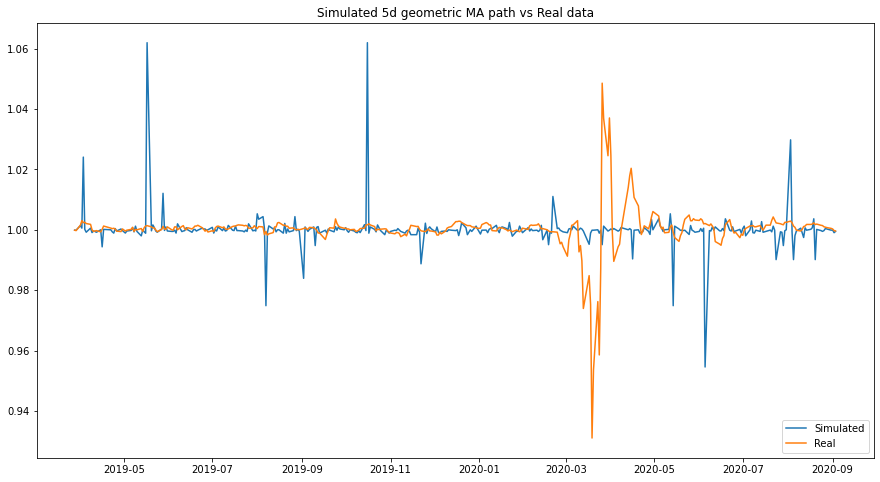

In [366]:
# Let's plot a generated sample against a real geometric time series curve
fig, ax = plt.subplots(figsize=(15,8))
ax.plot(geoMA_5d_stocks_p1_T.columns, sim_paths_matrix[0], label = 'Simulated')
ax.plot(geoMA_5d_stocks_p1_T.columns, geoMA_5d_stocks_p1_T.iloc[random_tickers_selected[0]], label = 'Real')
ax.set_title('Simulated 5d geometric MA path vs Real data')
Legend = ax.legend(loc='lower right')



In [367]:
sim_paths_matrix.shape

(10000, 363)

In [368]:
# Shuffle the generated curves
shuffled_array = np.random.permutation(sim_paths_matrix)# Split the simulated time series into a training and test set
x_train = shuffled_array[0:8000]
x_test = shuffled_array[8000:]

#x_train = shuffled_array[0:8000]
#x_test = shuffled_array[8000:]

In [369]:
x_train.shape

(8000, 363)

In [370]:
x_train.shape[1]

363

In [371]:
# Setup the network parameters:
original_dim = x_train.shape[1]
input_shape = (original_dim, )
intermediate_dim = 300
batch_size = 128
latent_dim = 2
epochs = 10

In [372]:
epochs

10

In [373]:
import os
import pandas as pd
import numpy as np
import scipy

from tensorflow.keras.layers import Lambda, Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.losses import mse, binary_crossentropy
#from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt
import argparse

from numpy.random import seed
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from tensorflow.keras import losses



In [374]:
# Map inputs to the latent distribution parameters:
# VAE model = encoder + decoder
# build encoder model
inputs = Input(shape=input_shape, name='encoder_input')
x = Dense(intermediate_dim, activation='relu')(inputs)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

In [375]:
# Use those parameters to sample new points from the latent space:
# reparameterization trick
# instead of sampling from Q(z|X), sample epsilon = N(0,I)
# z = z_mean + sqrt(var) * epsilon
def sampling(args):
    """Reparameterization trick by sampling from an isotropic unit Gaussian.
    # Arguments
        args (tensor): mean and log of variance of Q(z|X)
    # Returns
        z (tensor): sampled latent vector
    """

    z_mean, z_log_var = args
    
    #epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim),
     #                         mean=0., stddev=0.1)
    
    #return z_mean + K.exp(z_log_sigma) * epsilon
    
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    # by default, random_normal has mean = 0 and std = 1.0
    
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [376]:
# use reparameterization trick to push the sampling out as input
# note that "output_shape" isn't necessary with the TensorFlow backend
z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

In [377]:
# Instantiate the encoder model:
encoder = Model(inputs, z_mean)

In [378]:
encoder.summary()

Model: "model_20"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
encoder_input (InputLayer)   [(None, 363)]             0         
_________________________________________________________________
dense_59 (Dense)             (None, 300)               109200    
_________________________________________________________________
z_mean (Dense)               (None, 2)                 602       
Total params: 109,802
Trainable params: 109,802
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Build the decoder model:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = Dense(original_dim, activation='sigmoid')(x)

In [380]:
# Instantiate the decoder model:
decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
z_sampling (InputLayer)      [(None, 2)]               0         
_________________________________________________________________
dense_60 (Dense)             (None, 300)               900       
_________________________________________________________________
dense_61 (Dense)             (None, 363)               109263    
Total params: 110,163
Trainable params: 110,163
Non-trainable params: 0
_________________________________________________________________


In [381]:
# Instantiate the VAE model:
outputs = decoder(encoder(inputs))
vae = Model(inputs, outputs, name='vae_mlp')

In [382]:
# As in the Keras tutorial, we define a custom loss function:
def vae_loss(x, x_decoded_mean):
    xent_loss = losses.binary_crossentropy(x, x_decoded_mean)
    kl_loss = - 0.5 * K.mean(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
    return xent_loss + kl_loss

In [383]:
# As in the Keras tutorial, we define a custom loss function:
def vae_loss(inputs, outputs):
    xent_loss = losses.binary_crossentropy(inputs, outputs)
    kl_loss = - 0.5 * K.mean(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
    return xent_loss + kl_loss
  

In [384]:
from tensorflow.keras.optimizers import Adam

In [385]:
def sen_loss(encoder_inputs, decoder_outputs):
    sl = losses.binary_crossentropy(encoder_inputs, decoder_outputs)
    return K.sum(sl, axis=-1)

def kl_loss(z_mean, z_log_var):
    return - 0.5 * K.mean(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var))

optimizer = Adam(learning_rate=0.01)
vae.compile(optimizer=optimizer, loss=[sen_loss, kl_loss], loss_weights=[1.,1.])

In [299]:
# We compile the model:
#vae.compile(optimizer='rmsprop', loss=vae_loss)

In [300]:
#vae.add_loss(vae_loss)

In [386]:
# Finally, we train the model:
results = vae.fit(x_train, x_train,
        shuffle=True,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, x_test))

Epoch 1/10
63/63 [==============================] - 1s 5ms/step - loss: 4.7458 - val_loss: 1.8778
Epoch 2/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0475 - val_loss: 1.8209
Epoch 3/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0442 - val_loss: 1.8241
Epoch 4/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0421 - val_loss: 1.8317
Epoch 5/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0557 - val_loss: 1.9359
Epoch 6/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0742 - val_loss: 1.8644
Epoch 7/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0572 - val_loss: 1.8327
Epoch 8/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0467 - val_loss: 1.8623
Epoch 9/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0462 - val_loss: 1.8362
Epoch 10/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0464 - val_loss: 1.8346


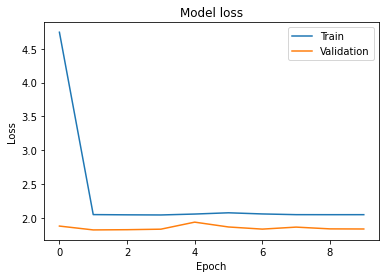

In [387]:
# Plot training & validation loss values
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Hacer Predicciones

In [388]:
stock_data_pct_change = stock_data.pct_change()
stock_data_pct_change.dropna(inplace = True)
stock_data_pct_change.tail()

,ESCALA,ACTICOB,ACTOTAL,ACTI500,ESFERA,ROBOTIK,DINAMO,SNX,SALUD,SPY,...,FINX,SNSR,AUSF,AIQ,CTEC,GNOM,MILN,KRMA,BUG,HERO
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-02-04,-0.005922,-0.006019,-0.006374,0.000746,-0.000010,0.003499,-0.004266,0.001322,-0.007173,0.004702,...,0.038826,0.000000,0.000325,0.021323,0.020777,0.014696,0.022982,0.005020,0.025723,0.032900
2022-02-08,0.001594,0.001147,0.001866,0.006554,-0.006514,0.012707,0.006251,0.006914,0.013479,0.004992,...,0.004558,0.013490,0.007511,0.004848,-0.006162,0.011965,0.003209,0.004371,0.018461,0.005926
2022-02-09,0.000466,0.000496,0.000764,0.014957,0.026678,0.027943,0.005493,0.015113,0.017830,0.014636,...,0.047187,0.030671,0.009724,0.025813,0.054685,0.042937,0.028526,0.017097,0.025650,0.029455
2022-02-10,0.003994,0.003811,0.004366,-0.011077,-0.011287,-0.012827,-0.000266,-0.008591,-0.012143,-0.017966,...,-0.022819,-0.025828,-0.013483,-0.017164,-0.031704,-0.028043,-0.020218,-0.017421,-0.001334,-0.025751
2022-02-11,0.003149,0.000003,0.000003,-0.018969,-0.018969,-0.018969,-0.007586,-0.015183,-0.013323,-0.019897,...,-0.033402,-0.023919,-0.005532,-0.033531,-0.028649,-0.023941,-0.027513,-0.019285,-0.023372,-0.018722


In [389]:
stock_data_pct_change=kweb

In [390]:
geoMA_5d_stocks = pd.DataFrame(columns = stock_data_pct_change.columns, index = stock_data_pct_change.index)

d = 5
for i in range(len(geoMA_5d_stocks.columns)):
    for j in range(d,len(geoMA_5d_stocks)):
        mult = 1
        for k in range(1,1+d):
            mult = mult * (stock_data_pct_change.loc[stock_data_pct_change.index[j-k]][geoMA_5d_stocks.columns[i]]+1)
            geoMA_5d_stocks.loc[geoMA_5d_stocks.index[j]][geoMA_5d_stocks.columns[i]] = np.power(mult,1/d)
            


In [391]:
geoMA_5d_stocks

,KWEB
Fecha,
2019-03-21,NaN
2019-03-22,NaN
2019-03-25,NaN
2019-03-26,NaN
2019-03-27,NaN
...,...
2022-02-04,1.012811
2022-02-08,1.013422
2022-02-09,0.99796


In [392]:
# Divide in two
geoMA_5d_stocks_p1_new = geoMA_5d_stocks.head(int(len(geoMA_5d_stocks)/2))
geoMA_5d_stocks_p2_new = geoMA_5d_stocks.tail(int(len(geoMA_5d_stocks)/2))# Transpose the dataframe for period 1
geoMA_5d_stocks_p1_T_new = geoMA_5d_stocks_p1_new.T

In [393]:
len(geoMA_5d_stocks_p1_new)

365

In [ ]:
#Probaremos para periodo 1

In [394]:
dataframe_to_test_p1 = geoMA_5d_stocks_p1.join(geoMA_5d_stocks_p1_new).fillna(1)

In [395]:
dataframe_to_test_p1

,ESCALA,ACTICOB,ACTOTAL,ACTI500,ESFERA,ROBOTIK,DINAMO,SNX,SALUD,SPY,...,SNSR,AUSF,AIQ,CTEC,GNOM,MILN,KRMA,BUG,HERO,KWEB
Fecha,,,,,,,,,,,,,,,,,,,,,
2019-03-28,1.000774,1.000021,1.000030,0.998552,0.997873,0.996549,0.998738,0.995468,0.995973,0.998647,...,0.991448,1.000750,0.997542,0.993431,0.994244,1.000282,0.999522,0.996504,0.997775,0.996336
2019-03-29,1.000725,1.000031,1.000034,0.997010,0.997286,0.994057,0.998762,0.994747,0.996548,0.997160,...,0.990191,0.999256,0.993554,0.991853,0.993319,0.998566,0.998328,0.994036,0.995630,0.996662
2019-04-01,1.000328,0.999726,0.999708,1.001927,1.001927,0.999396,1.000703,0.999610,1.002026,1.002303,...,0.999118,1.002584,1.000892,1.000100,1.006028,1.004524,1.003143,1.001570,1.002257,1.009793
2019-04-02,0.999504,0.999724,0.999720,1.004413,1.005546,1.004991,1.001243,1.001400,1.003585,1.004820,...,1.004470,1.004982,1.005556,1.005356,1.005486,1.005126,1.006209,1.005040,1.004962,1.013005
2019-04-03,0.999655,0.999706,0.999720,1.003024,1.003437,1.004028,1.000738,1.000856,1.001092,1.003427,...,1.004670,1.002480,1.004687,1.006155,1.004441,1.004827,1.004354,1.005152,1.004054,1.011510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28,0.999897,0.999569,0.999248,1.005828,1.005128,1.002523,1.000570,1.007893,0.999876,1.005872,...,1.001271,1.004343,1.008997,1.011542,0.993287,1.006398,1.006198,1.002179,1.003443,1.007767
2020-08-31,1.000093,0.999694,0.999891,1.006400,1.006376,1.003900,1.001812,1.009086,1.000752,1.006456,...,1.003508,1.005935,1.010672,1.012644,0.995516,1.006859,1.005655,1.004077,1.004562,1.009424
2020-09-01,1.000051,0.999866,0.999916,1.003712,1.004726,1.003487,1.000537,1.006258,1.003110,1.003699,...,1.000149,0.999561,1.008344,1.012210,0.993149,1.004190,1.004896,1.004218,1.001182,1.000000


In [396]:
matrix_to_test_p1 = dataframe_to_test_p1.T.values

In [397]:
encoded_p1 = encoder.predict(matrix_to_test_p1, batch_size=batch_size)

# Convert the predictions into a dataframe
encoded_p1_df = pd.DataFrame(data = encoded_p1, columns = ['x','y'], index = dataframe_to_test_p1.T.index)


In [398]:
encoded_p1_df.tail()

,x,y
MILN,7.701520,-22.093885
KRMA,7.698197,-22.085863
BUG,7.702709,-22.099232
HERO,7.706618,-22.113934
KWEB,7.699345,-22.101807


In [399]:
ref_point = encoded_p1_df.loc['KWEB'].values
encoded_p1_df['Distance'] = scipy.spatial.distance.cdist([ref_point], encoded_p1_df, metric='euclidean')[0]


In [400]:
closest_points = encoded_p1_df.sort_values('Distance', ascending = True)
closest_points_top50 = closest_points.head(51)[1:] #We take head(51), because the Futures reference point is the first entry
closest_points_top50['Ticker'] = closest_points_top50.index



In [401]:
closest_points

,x,y,Distance
KWEB,7.699345,-22.101807,0.000000
CXSE,7.698968,-22.100262,0.001590
SOCL,7.701998,-22.102371,0.002713
PALL,7.702256,-22.101337,0.002949
EDV,7.700900,-22.098757,0.003423
...,...,...,...
AMLP,7.682770,-22.038284,0.065649
XOP,7.679585,-22.032393,0.072172
OIH,7.680171,-22.025370,0.078805
XES,7.676136,-22.015995,0.088895


In [402]:
closest_points_top50.head()

,x,y,Distance,Ticker
CXSE,7.698968,-22.100262,0.001590,CXSE
SOCL,7.701998,-22.102371,0.002713,SOCL
PALL,7.702256,-22.101337,0.002949,PALL
EDV,7.700900,-22.098757,0.003423,EDV
IGV,7.702760,-22.100616,0.003617,IGV


In [403]:
ref_point

array([  7.6993446, -22.101807 ], dtype=float32)

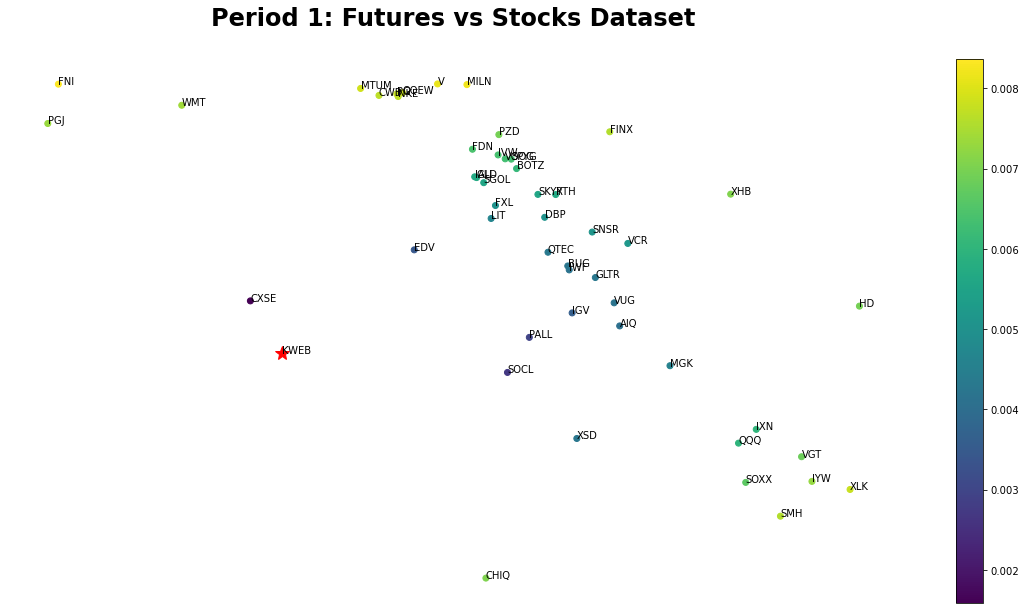

In [404]:
x_i = closest_points_top50['x']#*1000
y_i = closest_points_top50['y']#*100
d_i = closest_points_top50['Distance']
ticker_i = closest_points_top50['Ticker']
fig, ax = plt.subplots(figsize=(20, 10))
im = ax.scatter(x_i, y_i, c = d_i, cmap = 'viridis')
plt.plot(ref_point[0], ref_point[1],'r*', markersize = 15)
ax.annotate('KWEB',(ref_point[0], ref_point[1]))
plt.colorbar(im, ax=ax)
plt.axis('off')
ax.set_title('Period 1: Futures vs Stocks Dataset\n', fontsize = 24, fontweight='bold')
for i, txt in enumerate(ticker_i):
    ax.annotate(txt, (x_i[i], y_i[i]))

# Índice

Usaremos el proceso descrito anteriormente para crear un índice. Debido a la aleatoriedad del modelo VAE, no obtendremos la misma lista exacta de las 50 principales acciones en cada ejecución.

Para asegurarnos de obtener una representación justa de los 50 puntos más cercanos, ejecutaremos el modelo VAE 10 veces (reinicializándolo y reentrenándolo en cada ejecución). Luego, tomaremos los 50 puntos más cercanos encontrados en cada ejecución para crear un marco de datos más cercano_puntos_df marco de datos de longitud 500.

In [335]:
from datetime import date

In [339]:
today = date.today()
today_string = str(today.year)+str(today.month)+str(today.day)
n_trials = 3
path='/Users/CarlosCarrasco/Downloads/'

In [340]:
# network parameters
original_dim = x_train.shape[1]
input_shape = (original_dim, )
intermediate_dim = 300
batch_size = 128
latent_dim = 2
epochs = 10

In [428]:
for indice_guardar in range(n_trials): # Create the VAE model and get the predictions n_trials(=10) times.
    n_rows_sim_paths_matrix = n_tickers_selected * n_simpath_per_ticker
    sim_paths_matrix  = np.zeros((n_rows_sim_paths_matrix, len(geoMA_5d_stocks_p1_T.iloc[0])))
    for i in range(len(random_tickers_selected)):
        random_index = random_tickers_selected[i]
        rd_stock_logReturns = np.diff(np.log(geoMA_5d_stocks_p1_T.iloc[random_index].values.astype(np.float64)))
        #rd_stock_logReturns = np.diff(np.log(geoMA_5d_stocks_T.iloc[random_index]))
        for j in range(n_simpath_per_ticker):
            sim_path = np.zeros(len(geoMA_5d_stocks_p1_T.iloc[random_index]))
            sim_path[0] = geoMA_5d_stocks_p1_T.iloc[random_index][0]
            for k in range(1,len(sim_path)):
                sim_path[k] = sim_path[0]*np.exp(rd_stock_logReturns[np.random.randint(0, len(rd_stock_logReturns))])
            sim_paths_matrix[i*100+j] = sim_path   
    # Shuffle the generated curves
    shuffled_array = np.random.permutation(sim_paths_matrix)# Split the simulated time series into a training and test set
    x_train = shuffled_array[0:8000]
    x_test = shuffled_array[8000:]
    # Map inputs to the latent distribution parameters:
    # VAE model = encoder + decoder
    # build encoder model
    inputs = Input(shape=input_shape, name='encoder_input')
    x = Dense(intermediate_dim, activation='relu')(inputs)
    z_mean = Dense(latent_dim, name='z_mean')(x)
    z_log_var = Dense(latent_dim, name='z_log_var')(x)
    # use reparameterization trick to push the sampling out as input
    # note that "output_shape" isn't necessary with the TensorFlow backend
    z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])
    # Instantiate the encoder model:
    encoder = Model(inputs, z_mean)
    # Build the decoder model:
    latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
    x = Dense(intermediate_dim, activation='relu')(latent_inputs)
    outputs = Dense(original_dim, activation='sigmoid')(x)
    # Instantiate the decoder model:
    decoder = Model(latent_inputs, outputs, name='decoder')
    # Instantiate the VAE model:
    outputs = decoder(encoder(inputs))
    vae = Model(inputs, outputs, name='vae_mlp')
    vae.compile(optimizer=optimizer, loss=[sen_loss, kl_loss], loss_weights=[1.,1.])

    # Finally, we train the model:
    results = vae.fit(x_train, x_train,
            shuffle=True,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_test, x_test))
    
    
    dataframe_to_test_p1 = geoMA_5d_stocks_p1.join(geoMA_5d_stocks_p1_new).fillna(1)
    matrix_to_test_p1 = dataframe_to_test_p1.T.values
    
    
    
    encoded_p1 = encoder.predict(matrix_to_test_p1, batch_size=batch_size)

    # Convert the predictions into a dataframe
    encoded_p1_df = pd.DataFrame(data = encoded_p1, columns = ['x','y'], index = dataframe_to_test_p1.T.index)
    ref_point = encoded_p1_df.loc['KWEB'].values
    encoded_p1_df['Distance'] = scipy.spatial.distance.cdist([ref_point], encoded_p1_df, metric='euclidean')[0]
    closest_points = encoded_p1_df.sort_values('Distance', ascending = True)
    closest_points_top50 = closest_points.head(51)[1:] #We take head(51), because the Futures reference point is the first entry
    closest_points_top50['Ticker'] = closest_points_top50.index
    # Save the top 50 closest points obtained for the cuurent run in a .xlsx file
    loop_currentfilename = path + 'Futures_vs_stocks_period1_'+today_string+'_trial_'+str(indice_guardar+1)+'.xlsx'
    closest_points_top50.to_excel(loop_currentfilename)

Epoch 1/10
63/63 [==============================] - 1s 5ms/step - loss: 8.7299 - val_loss: 2.0144
Epoch 2/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0179 - val_loss: 1.9526
Epoch 3/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0108 - val_loss: 1.9525
Epoch 4/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0055 - val_loss: 1.9586
Epoch 5/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0049 - val_loss: 1.9696
Epoch 6/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0077 - val_loss: 1.9616
Epoch 7/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0056 - val_loss: 1.9612
Epoch 8/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0048 - val_loss: 1.9578
Epoch 9/10
63/63 [==============================] - 0s 4ms/step - loss: 1.9996 - val_loss: 1.9519
Epoch 10/10
63/63 [==============================] - 0s 4ms/step - loss: 2.0041 - val_loss: 1.9598
Epoch 1/10
63/63 [=

In [349]:
results_df = pd.DataFrame()
for f in range(n_trials):
    print(f)
    path = '/Users/CarlosCarrasco/Downloads/'+'Futures_vs_stocks_period1_'+today_string+'_trial_'+str(f+1)+'.xlsx'
    data = pd.read_excel(path)
    results_df = results_df.append(data)

0
1
2


In [351]:
results_df.head()

,Unnamed: 0,x,y,Distance,Ticker
0,REM,0.401267,0.297695,0.0,REM
1,EPHE,0.401267,0.297695,0.0,EPHE
2,ERUS,0.401267,0.297695,0.0,ERUS
3,EWT,0.401267,0.297695,0.0,EWT
4,DFJ,0.401267,0.297695,0.0,DFJ


In [352]:
sorted_by_dist = results_df.sort_values('Distance', ascending = True)

In [353]:


# We verify:
sorted_by_dist.head()



,Unnamed: 0,x,y,Distance,Ticker
0,REM,0.401267,0.297695,0.0,REM
21,INDY,-0.192529,-0.087704,0.0,INDY
20,EWA,-0.192529,-0.087704,0.0,EWA
19,DBJP,-0.192529,-0.087704,0.0,DBJP
18,EWZ,-0.192529,-0.087704,0.0,EWZ


In [354]:
len(sorted_by_dist)

150

In [355]:
sorted_by_dist.drop_duplicates(subset='Ticker', keep='first', inplace = True)

In [356]:
len(sorted_by_dist)

94

In [406]:
closest_points_top50

,x,y,Distance,Ticker
CXSE,7.698968,-22.100262,0.001590,CXSE
SOCL,7.701998,-22.102371,0.002713,SOCL
PALL,7.702256,-22.101337,0.002949,PALL
EDV,7.700900,-22.098757,0.003423,EDV
IGV,7.702760,-22.100616,0.003617,IGV
AIQ,7.703321,-22.101000,0.004057,AIQ
IWF,7.702726,-22.099348,0.004181,IWF
VUG,7.703255,-22.100319,0.004184,VUG
BUG,7.702709,-22.099232,0.004236,BUG
XSD,7.702816,-22.104319,0.004285,XSD


In [408]:
# Calculate the weights
top50 = closest_points_top50.head(50)
top50['Weight'] = (1/top50['Distance'])/np.sum(1/top50['Distance'])

<ipython-input-408-55fedb849f68>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top50['Weight'] = (1/top50['Distance'])/np.sum(1/top50['Distance'])


In [409]:
top50

,x,y,Distance,Ticker,Weight
CXSE,7.698968,-22.100262,0.001590,CXSE,0.066411
SOCL,7.701998,-22.102371,0.002713,SOCL,0.038924
PALL,7.702256,-22.101337,0.002949,PALL,0.035813
EDV,7.700900,-22.098757,0.003423,EDV,0.030847
IGV,7.702760,-22.100616,0.003617,IGV,0.029195
AIQ,7.703321,-22.101000,0.004057,AIQ,0.026030
IWF,7.702726,-22.099348,0.004181,IWF,0.025259
VUG,7.703255,-22.100319,0.004184,VUG,0.025239
BUG,7.702709,-22.099232,0.004236,BUG,0.024927
XSD,7.702816,-22.104319,0.004285,XSD,0.024647


In [410]:
#Get the stock prices for the top 50 stocks we selected
stock_data_top50 = stock_data[top50['Ticker']]

In [411]:
stock_data_top50.head()

,CXSE,SOCL,PALL,EDV,IGV,AIQ,IWF,VUG,BUG,XSD,...,FINX,CWB,NKE,PG,XLK,QQEW,MTUM,V,MILN,FNI
Fecha,,,,,,,,,,,,,,,,,,,,,
2019-03-20,37.588268,32.250000,152.130005,103.235970,208.363983,15.503407,147.171997,152.258163,15.714588,78.521233,...,25.841883,48.490517,84.554550,94.419838,71.086449,63.219284,107.922882,150.926010,23.168112,36.353458
2019-03-21,37.670944,32.380001,151.350006,103.398560,213.333054,15.829276,149.333420,154.483612,15.966695,80.867371,...,26.207054,48.953835,85.842041,95.134567,72.872086,64.221764,109.089798,152.938324,23.587688,36.522129
2019-03-22,36.751781,31.850000,146.979996,105.656555,207.042206,15.473783,146.096161,151.145477,15.545160,77.937187,...,25.618984,48.184738,80.165413,94.364143,71.154366,62.738804,107.854805,150.258484,23.032217,35.391041
2019-03-25,36.761501,31.740000,148.990005,106.135246,207.161453,15.396760,146.096161,151.106384,15.490766,77.224434,...,25.381859,48.129143,80.301956,94.642609,70.843826,62.649826,107.971489,150.219208,23.176043,35.500183
2019-03-26,36.780956,31.879999,145.410004,105.891380,208.373917,15.444159,146.800354,151.994629,15.569635,78.006470,...,25.950960,48.184738,81.326080,95.626534,71.232010,63.104607,108.681381,152.447510,23.239529,35.827606


In [412]:
#Get the stock prices on January 4th 2016
jan4_2016_stockPrice = np.zeros(len(stock_data_top50.columns))
for i in range(len(jan4_2016_stockPrice)):
    if stock_data_top50.columns[i] == top50['Ticker'].iloc[i]:
        jan4_2016_stockPrice[i] = stock_data_top50[stock_data_top50.columns[i]].iloc[0]



In [413]:
top50['Price Jan4_2016'] = jan4_2016_stockPrice

<ipython-input-413-9c83f72f2121>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top50['Price Jan4_2016'] = jan4_2016_stockPrice


In [414]:
top50

,x,y,Distance,Ticker,Weight,Price Jan4_2016
CXSE,7.698968,-22.100262,0.001590,CXSE,0.066411,37.588268
SOCL,7.701998,-22.102371,0.002713,SOCL,0.038924,32.250000
PALL,7.702256,-22.101337,0.002949,PALL,0.035813,152.130005
EDV,7.700900,-22.098757,0.003423,EDV,0.030847,103.235970
IGV,7.702760,-22.100616,0.003617,IGV,0.029195,208.363983
AIQ,7.703321,-22.101000,0.004057,AIQ,0.026030,15.503407
IWF,7.702726,-22.099348,0.004181,IWF,0.025259,147.171997
VUG,7.703255,-22.100319,0.004184,VUG,0.025239,152.258163
BUG,7.702709,-22.099232,0.004236,BUG,0.024927,15.714588
XSD,7.702816,-22.104319,0.004285,XSD,0.024647,78.521233


In [415]:
net_assets = 10000000 # We chose net assets = 10 million (in the currency of the stock market)

numShares = np.zeros(len(stock_data_top50.columns))
for i in range(len(jan4_2016_stockPrice)):
    if stock_data_top50.columns[i] == top50['Ticker'].iloc[i]:
        numShares[i] = int(net_assets*top50['Weight'].iloc[i]/top50['Price Jan4_2016'].iloc[i])
top50['numShares'] = numShares

<ipython-input-415-010d62554387>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top50['numShares'] = numShares


In [416]:
top50.head()

,x,y,Distance,Ticker,Weight,Price Jan4_2016,numShares
CXSE,7.698968,-22.100262,0.001590,CXSE,0.066411,37.588268,17667.0
SOCL,7.701998,-22.102371,0.002713,SOCL,0.038924,32.250000,12069.0
PALL,7.702256,-22.101337,0.002949,PALL,0.035813,152.130005,2354.0
EDV,7.700900,-22.098757,0.003423,EDV,0.030847,103.235970,2987.0
IGV,7.702760,-22.100616,0.003617,IGV,0.029195,208.363983,1401.0


In [417]:
stock_data_top50

,CXSE,SOCL,PALL,EDV,IGV,AIQ,IWF,VUG,BUG,XSD,...,FINX,CWB,NKE,PG,XLK,QQEW,MTUM,V,MILN,FNI
Fecha,,,,,,,,,,,,,,,,,,,,,
2019-03-20,37.588268,32.250000,152.130005,103.235970,208.363983,15.503407,147.171997,152.258163,15.714588,78.521233,...,25.841883,48.490517,84.554550,94.419838,71.086449,63.219284,107.922882,150.926010,23.168112,36.353458
2019-03-21,37.670944,32.380001,151.350006,103.398560,213.333054,15.829276,149.333420,154.483612,15.966695,80.867371,...,26.207054,48.953835,85.842041,95.134567,72.872086,64.221764,109.089798,152.938324,23.587688,36.522129
2019-03-22,36.751781,31.850000,146.979996,105.656555,207.042206,15.473783,146.096161,151.145477,15.545160,77.937187,...,25.618984,48.184738,80.165413,94.364143,71.154366,62.738804,107.854805,150.258484,23.032217,35.391041
2019-03-25,36.761501,31.740000,148.990005,106.135246,207.161453,15.396760,146.096161,151.106384,15.490766,77.224434,...,25.381859,48.129143,80.301956,94.642609,70.843826,62.649826,107.971489,150.219208,23.176043,35.500183
2019-03-26,36.780956,31.879999,145.410004,105.891380,208.373917,15.444159,146.800354,151.994629,15.569635,78.006470,...,25.950960,48.184738,81.326080,95.626534,71.232010,63.104607,108.681381,152.447510,23.239529,35.827606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-02-04,47.980000,48.299999,213.020004,129.440002,351.059998,28.260000,276.100006,287.670013,28.709999,200.389999,...,32.910000,76.610001,145.389999,161.529999,159.600006,106.540001,166.809998,228.019028,37.389999,44.930000
2022-02-08,47.610001,47.730000,208.479996,128.500000,353.109985,28.396999,277.079987,288.179993,29.240000,206.580002,...,33.060001,76.989998,143.529999,159.960007,160.500000,107.519997,167.529999,227.569763,37.509998,45.650002
2022-02-09,48.689999,49.439999,211.850006,128.789993,364.420013,29.129999,282.549988,294.119995,29.990000,214.619995,...,34.619999,78.510002,146.259995,159.600006,164.059998,110.080002,171.610001,230.494995,38.580002,47.220001


In [418]:
stock_index = np.zeros(len(stock_data_top50))
for i in range(len(stock_data_top50)):
    sum_num = 0
    sum_denom = 0
    for j in range(len(stock_data_top50.columns)):
        sum_num = sum_num + stock_data_top50[stock_data_top50.columns[j]].iloc[i]*top50['numShares'].iloc[j]
        sum_denom = sum_denom + stock_data_top50[stock_data_top50.columns[j]].iloc[0]*top50['numShares'].iloc[j]
    stock_index[i] = sum_num /sum_denom



In [419]:
stock_index_df = pd.DataFrame(stock_index*100, columns =  ['stock_index'], index = stock_data_top50.index)

<AxesSubplot:xlabel='Fecha'>

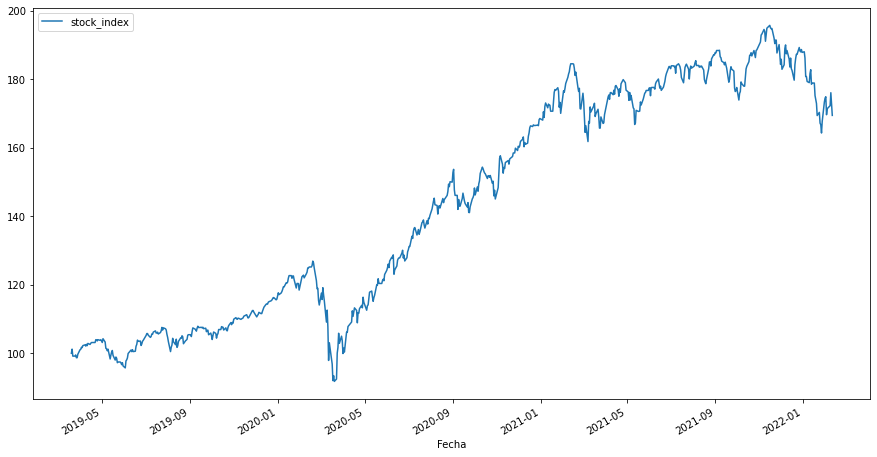

In [420]:
stock_index_df.plot(figsize=(15,8))

In [421]:
kweb

,KWEB
Fecha,
2019-03-21,0.005412
2019-03-22,-0.034022
2019-03-25,0.008694
2019-03-26,-0.001768
2019-03-27,0.003985
...,...
2022-02-04,0.016741
2022-02-08,0.016191
2022-02-09,0.038617


In [422]:
len(stock_index)

732

In [423]:
len(kweb)

731

In [424]:
futures_theoretical = np.zeros(len(stock_index_df))
futures_theoretical[0] = stock_index_df.iloc[0]
for i in range(len(futures_theoretical)-1):
      futures_theoretical[i+1] = (1+kweb.iloc[i])*futures_theoretical[i]


In [425]:
stock_index_df['KWEB'] = futures_theoretical

In [426]:
stock_index_df.head()

,stock_index,KWEB
Fecha,,
2019-03-20,100.000000,100.000000
2019-03-21,101.196619,100.541236
2019-03-22,99.158672,97.120599
2019-03-25,99.167416,97.964926
2019-03-26,99.500191,97.791723


<AxesSubplot:xlabel='Fecha'>

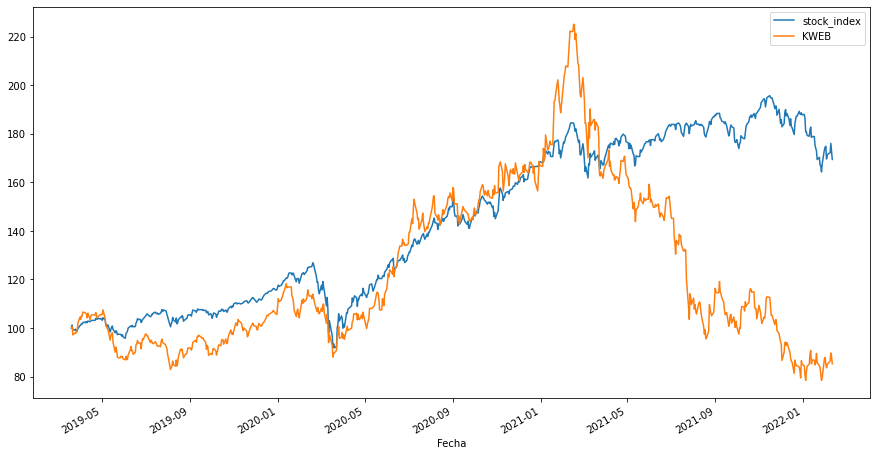

In [427]:
stock_index_df.plot(figsize=(15,8))

Nuestro índice tiene prácticamente la misma tendencia que los datos de futuros de referencia, excepto por la segunda mitad de 2021. No filtramos las acciones en busca de valores atípicos y límites de capitalización de mercado. Además, no hubo rebalanceos a lo largo de los dos períodos de tiempo observados e ignoramos las distribuciones.

Creemos que el uso de codificadores automáticos variacionales para construir un índice puede acelerar el desarrollo de nuevos índices en un mercado de valores con el que los analistas pueden no estar familiarizados. Además, podría ayudar a crear aún más índices de nicho para ser utilizados por los ETF o incluso nuevas posibilidades de inversión creativa para empresas de indexación directa en todo el mundo. 